## 1. Setup & Data Preparation
In this section, we configure dataset paths, import necessary libraries, and prepare our DataLoaders by splitting the dataset into training, validation, and test sets.

In [ ]:
CSV_PATH = "dataset/df.csv"
DATASET_ROOT = "dataset/HumanSegemntation"

In [3]:

import torch.nn as nn
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

from dataset import HumanSegmentationDataset
from model import BackgroundRemoval
from train import run_training
from evaluate import run_evaluation
from utils import plot_training_curves, visualize_predictions
from loss import BCEDiceLoss, FocalDiceLoss

In [33]:
df = pd.read_csv(CSV_PATH)
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_aug = A.Compose([A.Resize(256, 256), 
    ToTensorV2()])
test_aug = A.Compose([A.Resize(256, 256), 
    ToTensorV2()])

train_dataset = HumanSegmentationDataset(train_df, DATASET_ROOT, transform=train_aug)
val_dataset = HumanSegmentationDataset(val_df, DATASET_ROOT, transform=test_aug)
test_dataset = HumanSegmentationDataset(test_df, DATASET_ROOT, transform=test_aug)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

## 2. Baseline Model
Here we define and train a baseline background removal model. This model uses a standard encoder-decoder architecture **without** residual connections.

In [8]:
def get_baseline_model():
    return BackgroundRemoval(use_residual=False)

In [ ]:
results_baseline = run_training(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    lr=1e-3,
    checkpoint_path="models/baseline_model.pth",
    model_class=get_baseline_model,
    loss_class=nn.BCEWithLogitsLoss
)

plot_training_curves(
    checkpoint_path="models/baseline_model.pth", 
    title=f"Baseline (BCE + Conv) - Best Val IoU: {results_baseline['best_iou']:.4f}"
)


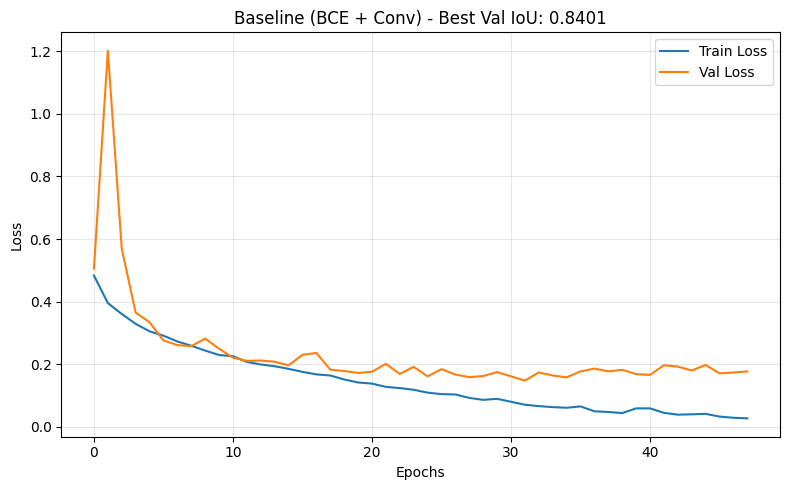

In [52]:
plot_training_curves(
    checkpoint_path="models/baseline_model.pth", 
    title=f"Baseline (BCE + Conv) - Best Val IoU: {results_baseline['best_iou']:.4f}"
)


## 3. Baseline Model Evaluation
After training, we load the best weights for the baseline model and evaluate its performance on the test set. We also visualize the predicted masks to see where the model struggles.

In [10]:
import torch
from utils import evaluate_thresholds

baseline_model = get_baseline_model()
baseline_model.load_state_dict(torch.load("models/baseline_model.pth")["model_state_dict"])
baseline_model = baseline_model.to("cuda" if torch.cuda.is_available() else "cpu")

print("Finding optimal threshold on Validation Set...")
threshold_results = evaluate_thresholds(
    model=baseline_model, 
    data_loader=val_loader, 
    device="cuda" if torch.cuda.is_available() else "cpu"
)


Finding optimal threshold on Validation Set...
Threshold: 0.3 | IoU: 0.8510 | Dice: 0.9114 | Prec: 0.8961 | Rec: 0.9455 | BF1: 0.7507 | BIoU: 0.5653
Threshold: 0.4 | IoU: 0.8530 | Dice: 0.9127 | Prec: 0.9060 | Rec: 0.9370 | BF1: 0.7557 | BIoU: 0.5765
Threshold: 0.5 | IoU: 0.8530 | Dice: 0.9127 | Prec: 0.9146 | Rec: 0.9280 | BF1: 0.7586 | BIoU: 0.5812
Threshold: 0.6 | IoU: 0.8509 | Dice: 0.9114 | Prec: 0.9224 | Rec: 0.9178 | BF1: 0.7588 | BIoU: 0.5798


In [27]:
print("--- Baseline: Standard Test Set ---")
test_metrics = run_evaluation(
    test_loader=test_loader,
    checkpoint_path="models/baseline_model.pth",
    threshold=0.4,
    postprocess=False,
    output_json="baseline_test_results.json",
    model_class=get_baseline_model
)

print("\n--- Baseline: Challenge Set ---")
CHALLENGE_ROOT = "Challenge_Set/"
challenge_df = pd.read_csv("Challenge_Set/challenge.csv")
challenge_dataset = HumanSegmentationDataset(challenge_df, CHALLENGE_ROOT, transform=test_aug)
challenge_loader = DataLoader(challenge_dataset, batch_size=8, shuffle=False)

challenge_metrics = run_evaluation(
    test_loader=challenge_loader,
    checkpoint_path="models/baseline_model.pth",
    threshold=0.4,
    postprocess=False,
    output_json="baseline_challenge_results.json",
    model_class=get_baseline_model
)


--- Baseline: Standard Test Set ---
Using device: cuda
Loaded checkpoint from /kaggle/working/models/baseline_model.pth
Evaluating with threshold 0.4 | Postprocess: False | Boundary Tolerance: 5...

--- Final Metrics ---
Iou: 0.8337
Dice: 0.9001
Precision: 0.8929
Recall: 0.9274
Boundary_f1: 0.7228
Boundary_iou: 0.5448

Saved metrics to baseline_test_results.json

--- Baseline: Challenge Set ---
Using device: cuda
Loaded checkpoint from /kaggle/working/models/baseline_model.pth
Evaluating with threshold 0.4 | Postprocess: False | Boundary Tolerance: 5...

--- Final Metrics ---
Iou: 0.7717
Dice: 0.8581
Precision: 0.8708
Recall: 0.8705
Boundary_f1: 0.6627
Boundary_iou: 0.4110

Saved metrics to baseline_challenge_results.json


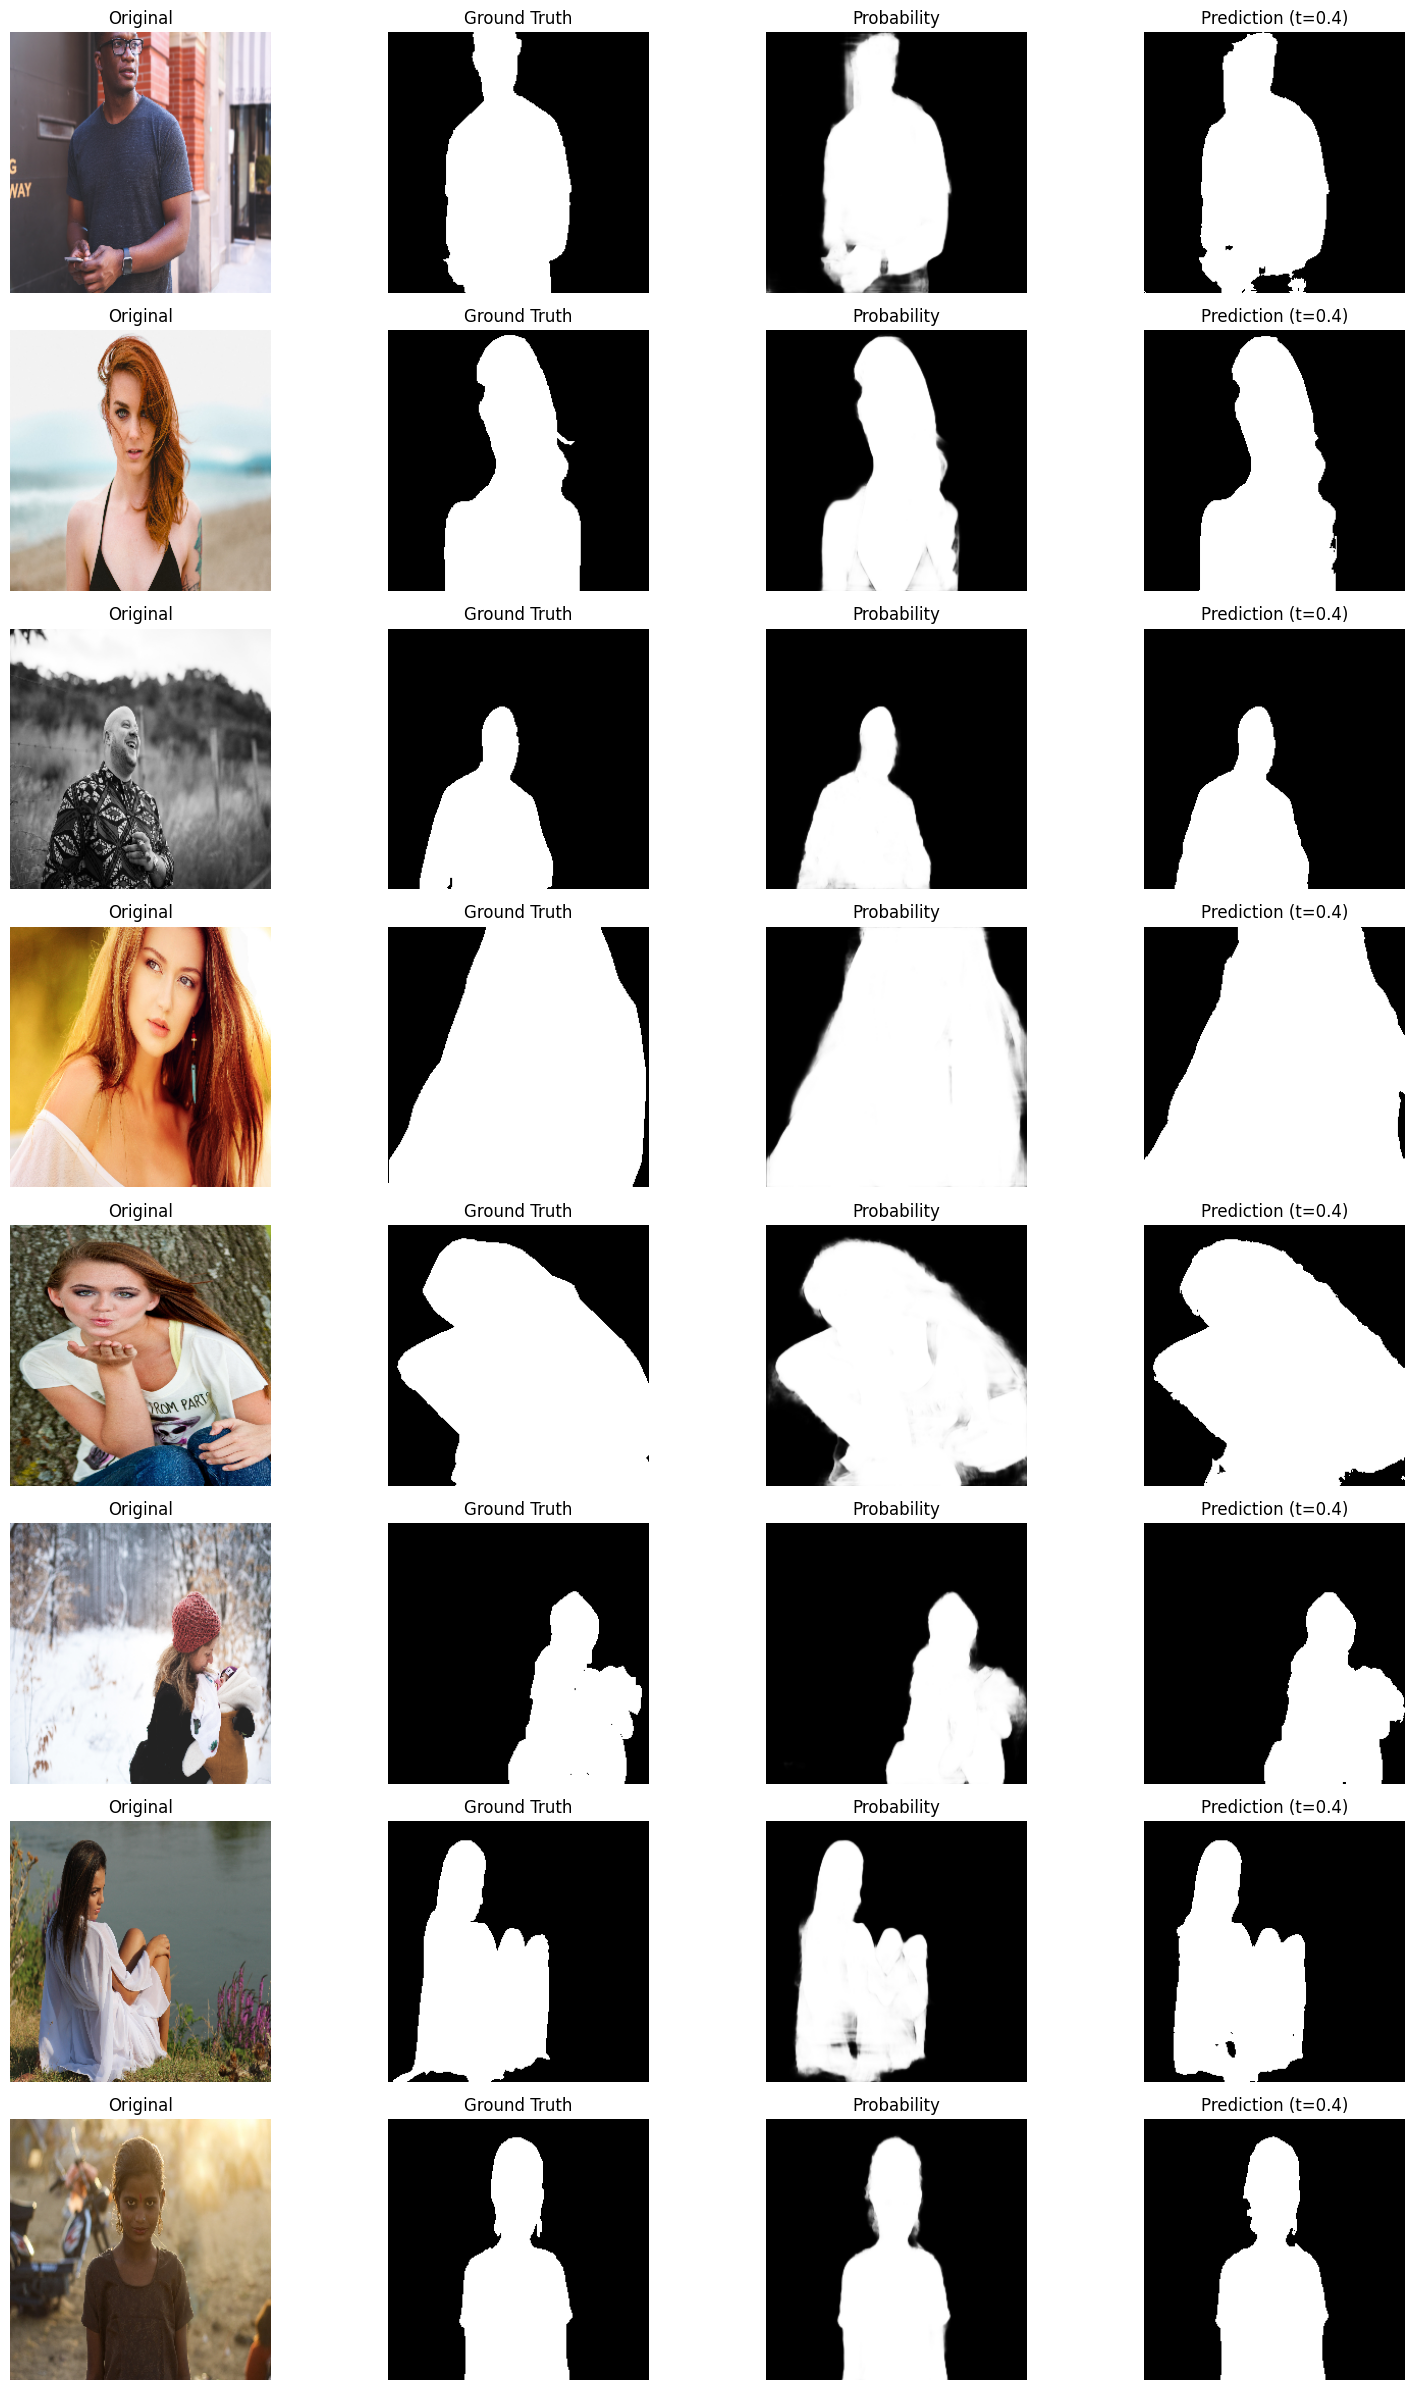

In [30]:
visualize_predictions(
    baseline_model,
    val_loader,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

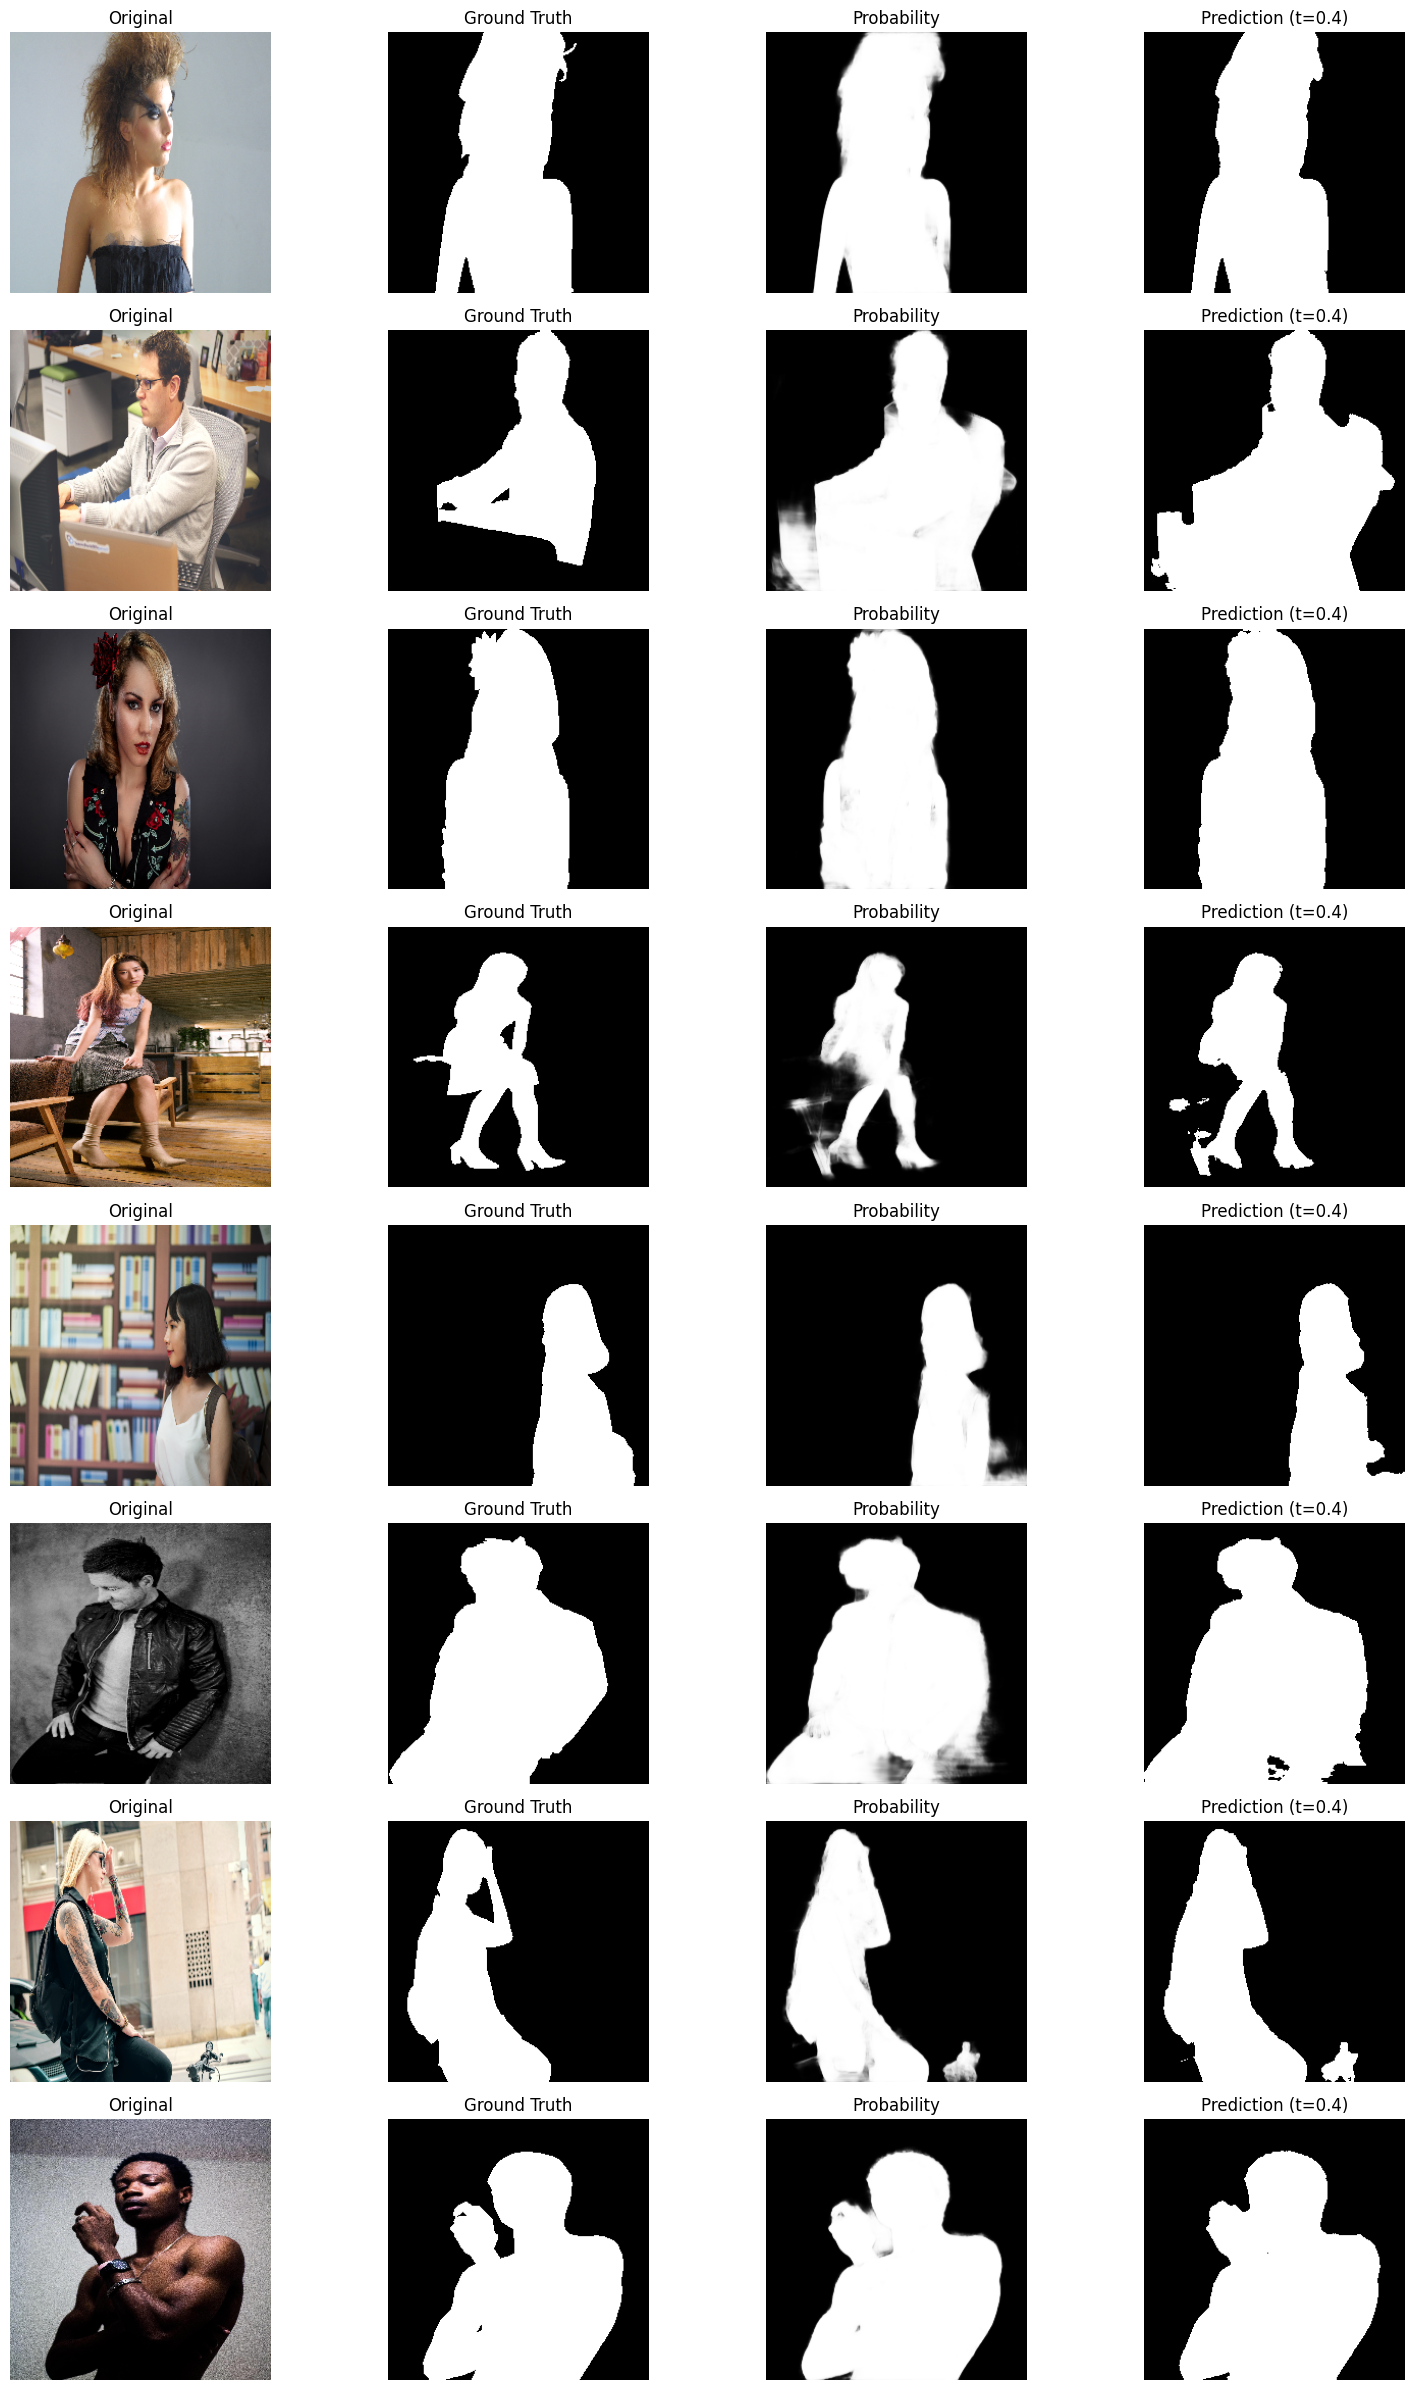

In [31]:
visualize_predictions(
    baseline_model,
    test_loader,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

## 4. Advanced Model (Residual Connections & Data Augmentation)
To improve performance, we introduce data augmentations (like Affine transforms, ColorJitter, and Horizontal flips). We also update the dataset loaders to apply these augmentations.

In [28]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGE_SIZE = (256, 256)

train_aug = A.Compose([
    A.Resize(height=IMAGE_SIZE[0], width=IMAGE_SIZE[1]),
    
    A.HorizontalFlip(p=0.5),
    
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(-0.05, 0.05),
        rotate=(-15, 15),
        p=0.5
    ),
    
    A.RandomBrightnessContrast(p=0.3),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    
    ToTensorV2(),
])

test_aug = A.Compose([
    A.Resize(height=IMAGE_SIZE[0], width=IMAGE_SIZE[1]),
    ToTensorV2(),
])

In [31]:
df = pd.read_csv(CSV_PATH)
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_dataset = HumanSegmentationDataset(train_df, DATASET_ROOT, transform=train_aug)
val_dataset = HumanSegmentationDataset(val_df, DATASET_ROOT, transform=test_aug)
test_dataset = HumanSegmentationDataset(test_df, DATASET_ROOT, transform=test_aug)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

We define a more advanced architecture by enabling **residual connections**, which helps the model learn more robust features and prevents vanishing gradients.

In [30]:
def get_res_model():
    return BackgroundRemoval(use_residual=True)

In [32]:
results_res = run_training(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    lr=1e-3,
    checkpoint_path="models/res_model.pth",
    model_class=get_res_model,
    loss_class=FocalDiceLoss
)


Using device: cuda
Starting training...

Epoch 1/50
Train loss: 0.27988
Val loss: 0.32888 | Val iou: 0.51721 | Val dice: 0.64944 | Val bf1: 0.18786 | Val biou: 0.10557
[*] Saved better model with IoU: 0.5172

Epoch 2/50
Train loss: 0.23608
Val loss: 0.28008 | Val iou: 0.49379 | Val dice: 0.62323 | Val bf1: 0.13858 | Val biou: 0.07943

Epoch 3/50
Train loss: 0.21678
Val loss: 0.24142 | Val iou: 0.56902 | Val dice: 0.69006 | Val bf1: 0.24452 | Val biou: 0.14210
[*] Saved better model with IoU: 0.5690

Epoch 4/50
Train loss: 0.19987
Val loss: 0.20922 | Val iou: 0.59088 | Val dice: 0.71501 | Val bf1: 0.37403 | Val biou: 0.22199
[*] Saved better model with IoU: 0.5909

Epoch 5/50
Train loss: 0.18442
Val loss: 0.18911 | Val iou: 0.61240 | Val dice: 0.73065 | Val bf1: 0.40839 | Val biou: 0.24564
[*] Saved better model with IoU: 0.6124

Epoch 6/50
Train loss: 0.17205
Val loss: 0.15949 | Val iou: 0.66591 | Val dice: 0.77377 | Val bf1: 0.41828 | Val biou: 0.24875
[*] Saved better model with IoU:

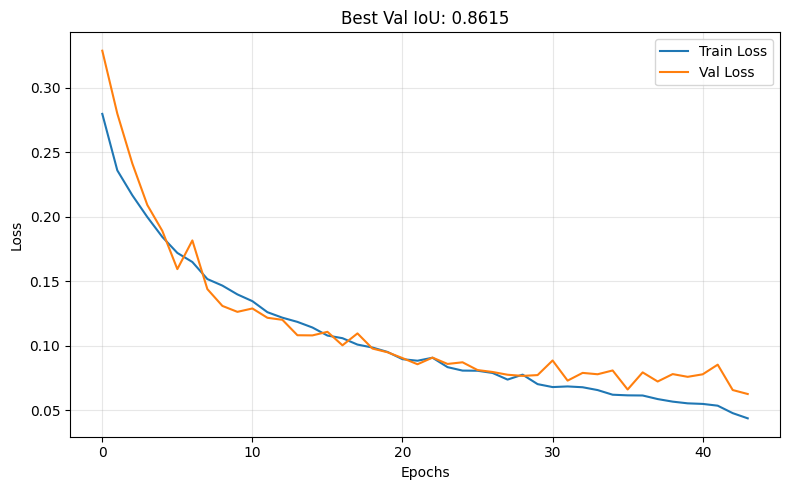

In [33]:
plot_training_curves(
    checkpoint_path="models/res_model.pth", 
    title=f"Best Val IoU: {results_res['best_iou']:.4f}"
)

## 5. Advanced Model Evaluation
Finally, we load the best weights for the residual model, evaluate its metrics on the test set, and visualize the predictions. The residual connections and data augmentations should yield noticeably better segmentation masks compared to the baseline.

In [34]:
import torch
from utils import evaluate_thresholds

res_model = get_res_model()
res_model.load_state_dict(torch.load("models/res_model.pth")["model_state_dict"])
res_model = res_model.to("cuda" if torch.cuda.is_available() else "cpu")

print("Finding optimal threshold on Validation Set...")
threshold_results = evaluate_thresholds(
    model=res_model, 
    data_loader=val_loader, 
    device="cuda" if torch.cuda.is_available() else "cpu"
)


Finding optimal threshold on Validation Set...
Threshold: 0.3 | IoU: 0.8596 | Dice: 0.9175 | Prec: 0.8974 | Rec: 0.9539 | BF1: 0.7570 | BIoU: 0.5460
Threshold: 0.4 | IoU: 0.8615 | Dice: 0.9189 | Prec: 0.9074 | Rec: 0.9451 | BF1: 0.7614 | BIoU: 0.5530
Threshold: 0.5 | IoU: 0.8609 | Dice: 0.9187 | Prec: 0.9168 | Rec: 0.9344 | BF1: 0.7617 | BIoU: 0.5540
Threshold: 0.6 | IoU: 0.8578 | Dice: 0.9169 | Prec: 0.9259 | Rec: 0.9215 | BF1: 0.7587 | BIoU: 0.5503


In [35]:
print("--- Standard Test Set ---")
test_metrics = run_evaluation(
    test_loader=test_loader,
    checkpoint_path="models/res_model.pth",
    threshold=0.4,
    postprocess=False,
    output_json="res_model_test_results.json",
    model_class=get_res_model
)

print("\n--- Challenge Set ---")
CHALLENGE_ROOT = "Challenge_Set/"
challenge_df = pd.read_csv("Challenge_Set/challenge.csv")
challenge_dataset = HumanSegmentationDataset(challenge_df, CHALLENGE_ROOT, transform=test_aug)
challenge_loader = DataLoader(challenge_dataset, batch_size=8, shuffle=False)

challenge_metrics = run_evaluation(
    test_loader=challenge_loader,
    checkpoint_path="models/res_model.pth",
    threshold=0.4,
    postprocess=False,
    output_json="res_model_challenge_results.json",
    model_class=get_res_model
)


--- Standard Test Set ---
Using device: cuda
Loaded checkpoint from models/res_model.pth
Evaluating with threshold 0.4 | Postprocess: False | Boundary Tolerance: 5...

--- Final Metrics ---
Iou: 0.8423
Dice: 0.9065
Precision: 0.8944
Recall: 0.9372
Boundary_f1: 0.7272
Boundary_iou: 0.5222

Saved metrics to res_model_test_results.json

--- Challenge Set ---
Using device: cuda
Loaded checkpoint from models/res_model.pth
Evaluating with threshold 0.4 | Postprocess: False | Boundary Tolerance: 5...

--- Final Metrics ---
Iou: 0.8088
Dice: 0.8845
Precision: 0.9097
Recall: 0.8742
Boundary_f1: 0.6895
Boundary_iou: 0.4408

Saved metrics to res_model_challenge_results.json


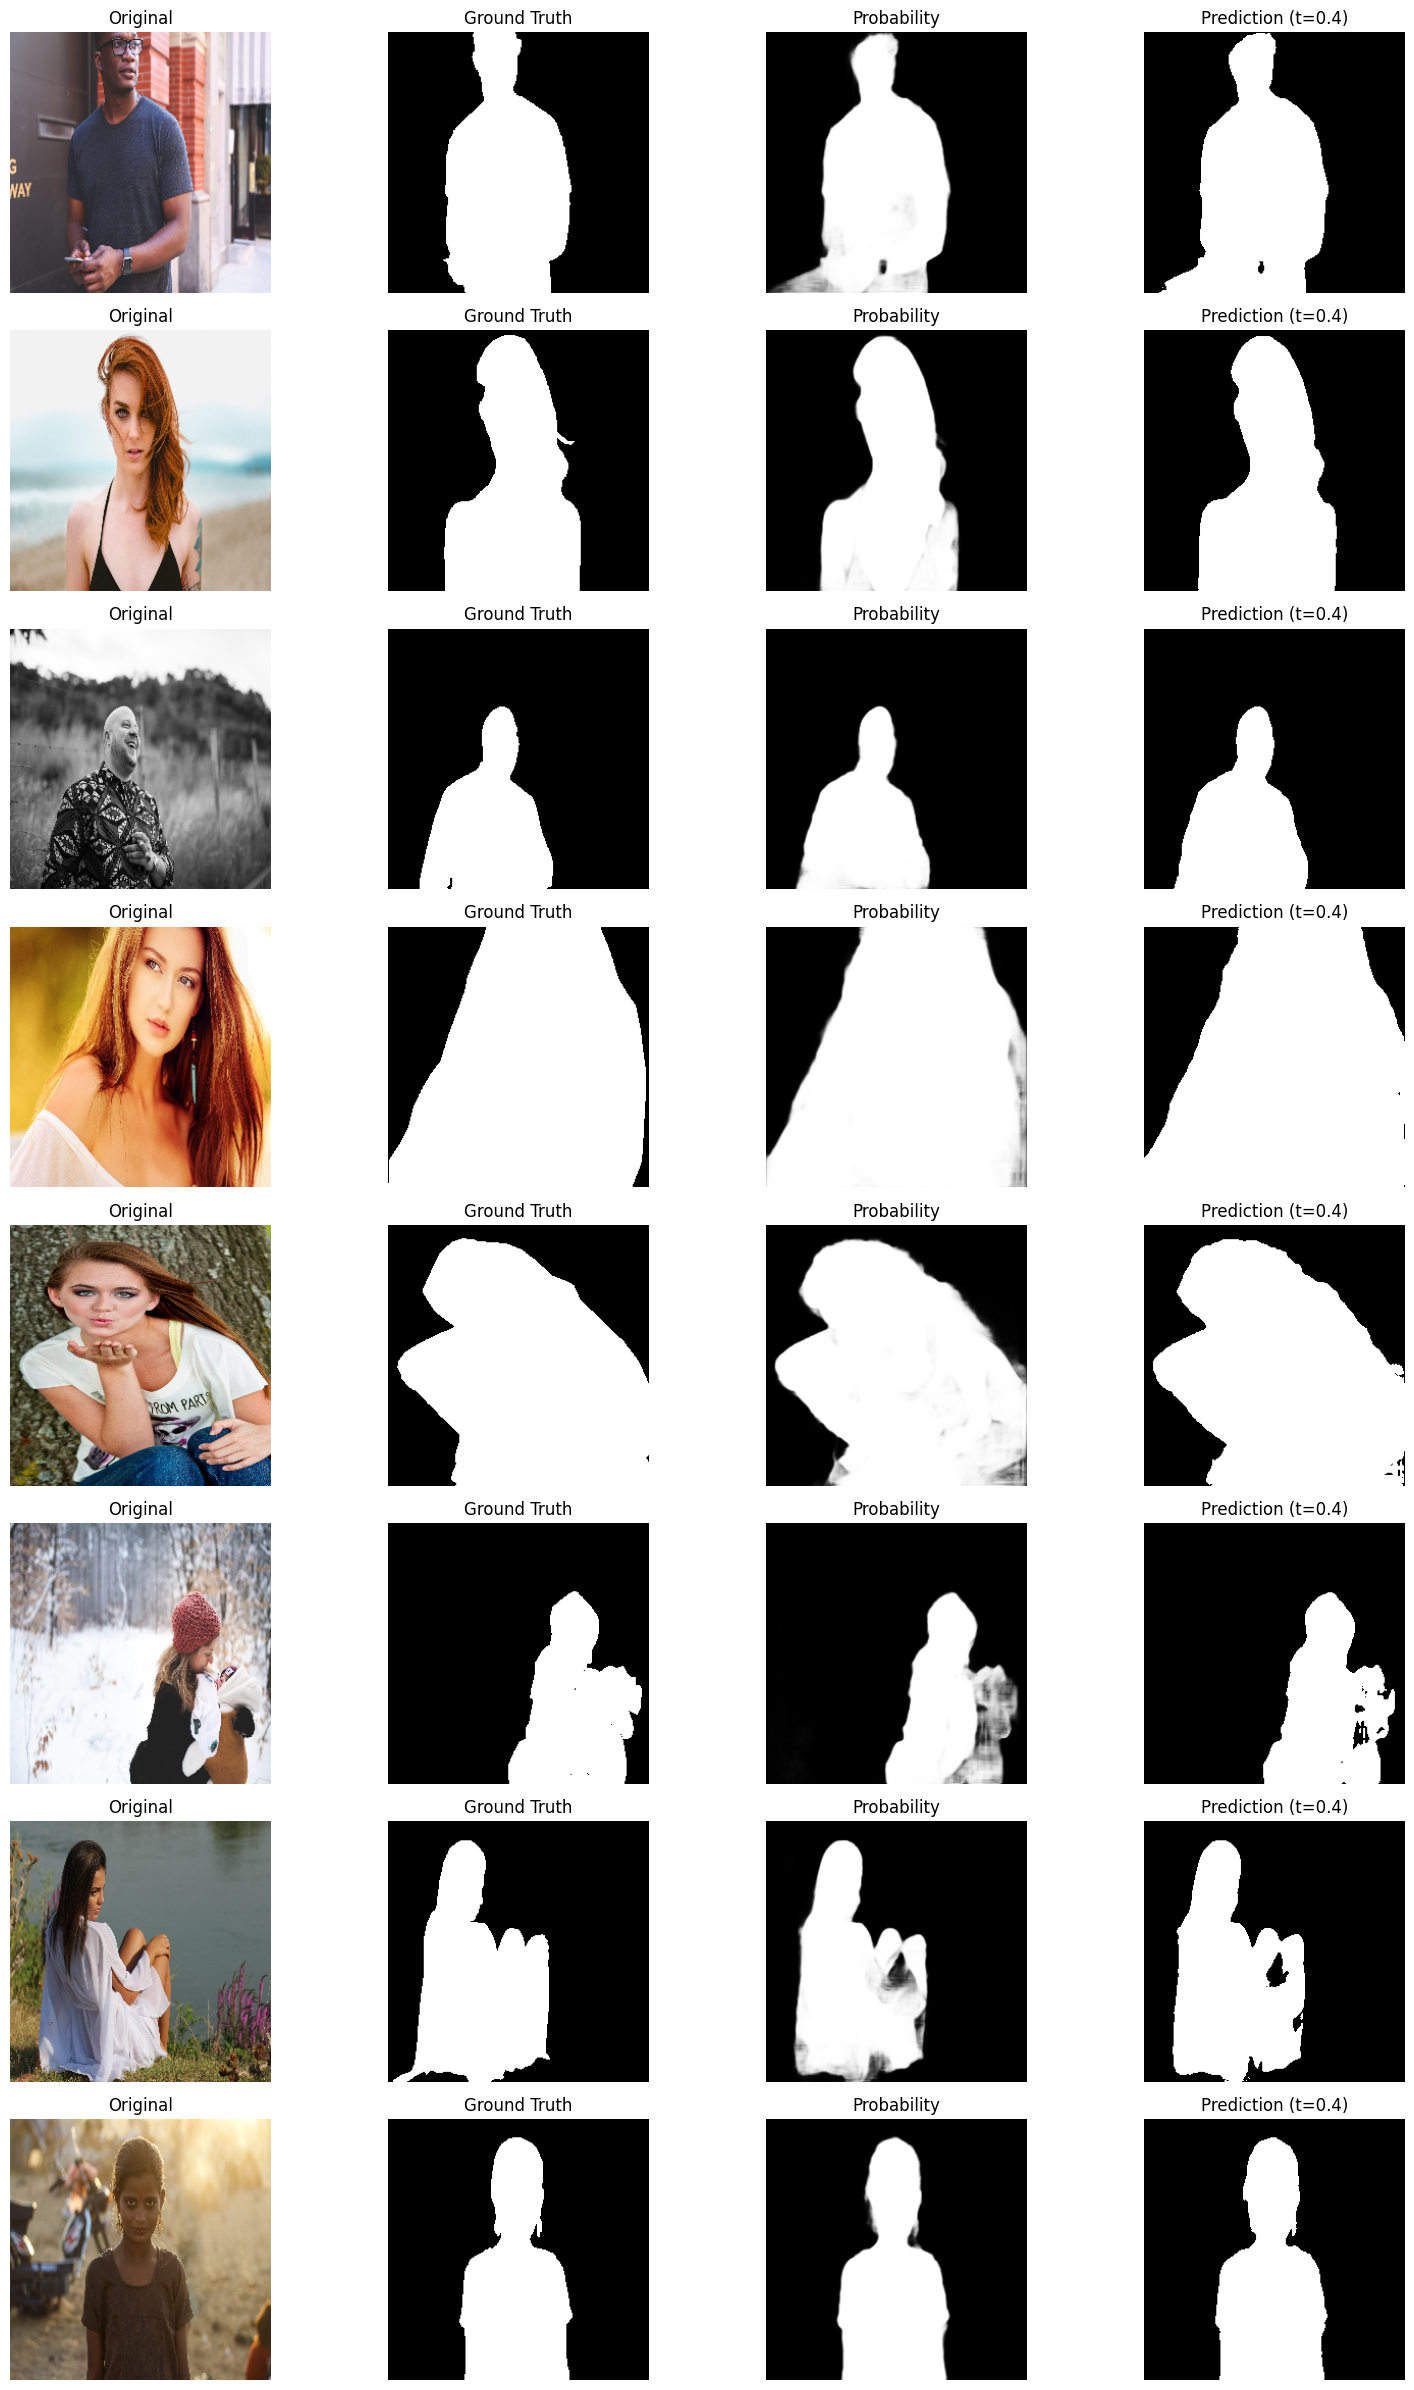

In [36]:
visualize_predictions(
    res_model,val_loader,device="cuda" if torch.cuda.is_available() else "cpu",threshold = 0.4
)

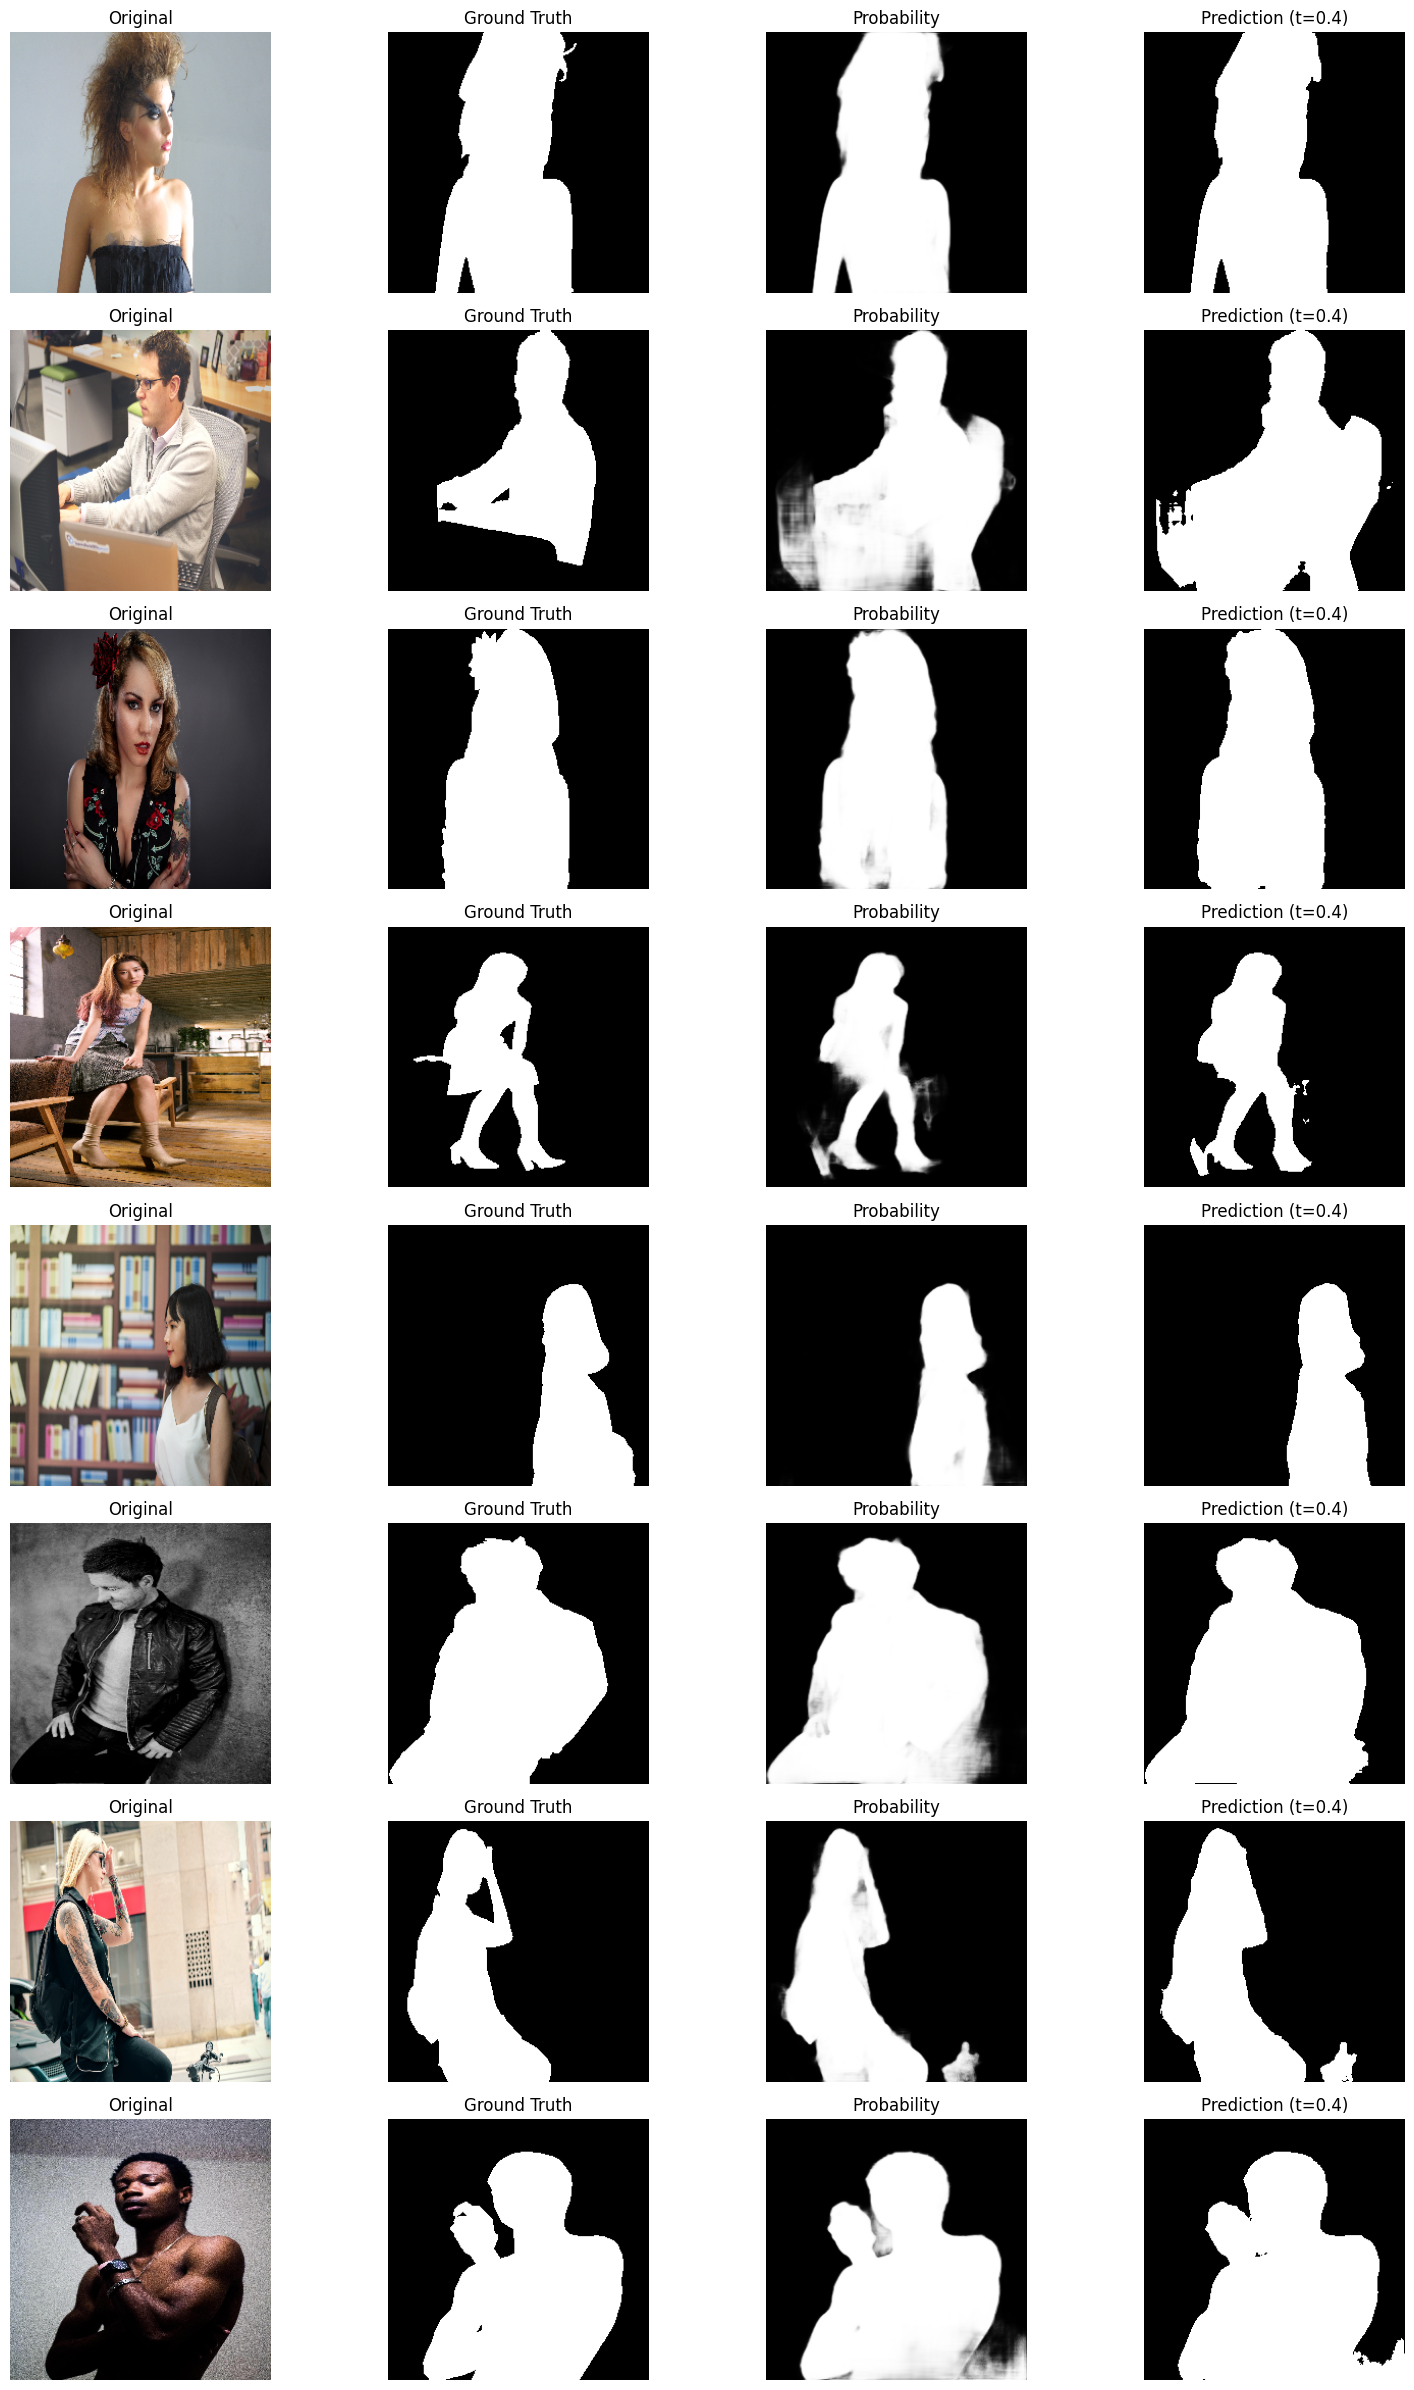

In [37]:
visualize_predictions(
    res_model,test_loader,device="cuda" if torch.cuda.is_available() else "cpu",threshold = 0.4
)